# Pharmacy Access in Northern Vermont

Driving time analysis for pharmacies in **Caledonia**, **Orleans**, **Lamoille**, and **Washington** counties.

This notebook:
1. Loads pharmacy locations (NPPES NPI-sourced, pre-geocoded)
2. Clusters nearby pharmacies into centroids to reduce API calls
3. Downloads county boundaries from US Census TIGER/Line
4. Loads address sample points from CSV files
5. Computes driving time to the nearest pharmacy via the **Google Routes API**
6. Visualizes results as an interactive heat map
7. Reports descriptive statistics on pharmacy access

**Budget**: Google Routes API Compute Route Matrix Essentials — 10,000 free elements/month, then $5/1,000. Hard cap: **12,000 elements ($10 max spend)**.

In [1]:
import json
import math
import os
import time
from pathlib import Path

from dotenv import load_dotenv
load_dotenv(Path("../.env"))

import folium
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import requests
import seaborn as sns
from shapely.geometry import Point

DATA_DIR = Path("../data")
DATA_DIR.mkdir(exist_ok=True)

ADDRESSES_DIR = DATA_DIR / "addresses"

TARGET_COUNTIES = {
    "Caledonia": "50005",
    "Orleans": "50019",
    "Lamoille": "50015",
    "Washington": "50023",
}
COUNTY_FIPS_TO_NAME = {v: k for k, v in TARGET_COUNTIES.items()}

GOOGLE_API_KEY = os.environ.get("GOOGLE_ROUTES_API_KEY", "")
ROUTE_MATRIX_URL = "https://routes.googleapis.com/distanceMatrix/v2:computeRouteMatrix"
ELEMENT_BUDGET = 12_000  # 10k free + $10 at $5/1000
CLUSTER_RADIUS_MILES = 1.5
TOP_K_CANDIDATES = 4

assert GOOGLE_API_KEY, (
    "Set GOOGLE_ROUTES_API_KEY in .env before running."
)
print(f"API key loaded: {GOOGLE_API_KEY[:8]}...")

API key loaded: AIzaSyAs...


## 1. Pharmacy Locations

Discover all pharmacies in and around the four target counties using the **Google Places API (New)** Nearby Search. We tile overlapping 30 km-radius search circles across the region plus a ~20-mile buffer, capturing pharmacies in neighboring Vermont counties and across the New Hampshire border. Results are deduplicated by `place_id` and cached to disk.

In [5]:
PHARMACY_CACHE = DATA_DIR / "pharmacies.json"
PLACES_URL = "https://places.googleapis.com/v1/places:searchNearby"

# Bounding box covering the 4 target counties + ~20-mile buffer,
# reaching into neighboring VT counties and across the NH border.
SEARCH_BBOX = {"lat_min": 43.76, "lat_max": 45.30, "lon_min": -73.30, "lon_max": -71.26}
SEARCH_RADIUS_M = 30_000  # 30 km per circle


def search_nearby_pharmacies(center_lat, center_lon, radius_m, api_key):
    body = {
        "includedTypes": ["pharmacy"],
        "locationRestriction": {
            "circle": {
                "center": {"latitude": center_lat, "longitude": center_lon},
                "radius": radius_m,
            }
        },
        "maxResultCount": 20,
    }
    headers = {
        "Content-Type": "application/json",
        "X-Goog-Api-Key": api_key,
        "X-Goog-FieldMask": (
            "places.displayName,places.formattedAddress,"
            "places.location,places.id,places.businessStatus"
        ),
    }
    resp = requests.post(PLACES_URL, json=body, headers=headers, timeout=30)
    resp.raise_for_status()
    return resp.json().get("places", [])


def fetch_all_pharmacies(bbox, radius_m, api_key):
    """Tile overlapping search circles across bbox, deduplicate by place_id."""
    mid_lat = (bbox["lat_min"] + bbox["lat_max"]) / 2
    # ~60% of diameter for overlap between circles
    lat_step = radius_m * 1.2 / 111_000
    lon_step = lat_step / math.cos(math.radians(mid_lat))

    lats = np.arange(bbox["lat_min"], bbox["lat_max"] + lat_step * 0.1, lat_step)
    lons = np.arange(bbox["lon_min"], bbox["lon_max"] + lon_step * 0.1, lon_step)
    print(f"  Search grid: {len(lats)} × {len(lons)} = {len(lats) * len(lons)} circles "
          f"(radius {radius_m / 1000:.0f} km)")

    seen = {}
    n_calls = 0
    for lat in lats:
        for lon in lons:
            places = search_nearby_pharmacies(lat, lon, radius_m, api_key)
            n_calls += 1
            for p in places:
                pid = p["id"]
                if pid not in seen:
                    addr = p.get("formattedAddress", "")
                    parts = [s.strip() for s in addr.split(",")]
                    city = parts[1] if len(parts) >= 3 else ""
                    seen[pid] = {
                        "place_id": pid,
                        "name": p.get("displayName", {}).get("text", ""),
                        "address": addr,
                        "city": city,
                        "lat": p["location"]["latitude"],
                        "lon": p["location"]["longitude"],
                        "business_status": p.get("businessStatus", "OPERATIONAL"),
                    }
            time.sleep(0.1)

    print(f"  {n_calls} API calls → {len(seen)} unique pharmacies")
    return list(seen.values())


if PHARMACY_CACHE.exists():
    all_pharmacies = json.loads(PHARMACY_CACHE.read_text())
    print(f"Loaded {len(all_pharmacies)} pharmacies from cache ({PHARMACY_CACHE.name})")
else:
    print("Searching for pharmacies via Google Places API (Nearby Search)...")
    all_pharmacies = fetch_all_pharmacies(SEARCH_BBOX, SEARCH_RADIUS_M, GOOGLE_API_KEY)
    PHARMACY_CACHE.write_text(json.dumps(all_pharmacies, indent=2))
    print(f"Cached to {PHARMACY_CACHE.name}")

Loaded 224 pharmacies from cache (pharmacies.json)


In [6]:
mid_lat = (SEARCH_BBOX["lat_min"] + SEARCH_BBOX["lat_max"]) / 2
mid_lon = (SEARCH_BBOX["lon_min"] + SEARCH_BBOX["lon_max"]) / 2
lat_step = SEARCH_RADIUS_M * 1.2 / 111_000
lon_step = lat_step / math.cos(math.radians(mid_lat))

lats = np.arange(SEARCH_BBOX["lat_min"], SEARCH_BBOX["lat_max"] + lat_step * 0.1, lat_step)
lons = np.arange(SEARCH_BBOX["lon_min"], SEARCH_BBOX["lon_max"] + lon_step * 0.1, lon_step)

m = folium.Map(location=[mid_lat, mid_lon], zoom_start=8, tiles="cartodbpositron")

for lat in lats:
    for lon in lons:
        folium.Circle(
            location=[lat, lon],
            radius=SEARCH_RADIUS_M,
            color="#3388ff",
            weight=1,
            fill=True,
            fill_opacity=0.05,
        ).add_to(m)

for p in all_pharmacies:
    color = "red" if p.get("business_status") == "CLOSED_PERMANENTLY" else "green"
    folium.CircleMarker(
        location=[p["lat"], p["lon"]],
        radius=5,
        color=color,
        fill=True,
        fill_opacity=0.8,
        tooltip=f"{p['name']} — {p['address']}",
    ).add_to(m)

# Draw bounding box
bbox_coords = [
    [SEARCH_BBOX["lat_min"], SEARCH_BBOX["lon_min"]],
    [SEARCH_BBOX["lat_min"], SEARCH_BBOX["lon_max"]],
    [SEARCH_BBOX["lat_max"], SEARCH_BBOX["lon_max"]],
    [SEARCH_BBOX["lat_max"], SEARCH_BBOX["lon_min"]],
    [SEARCH_BBOX["lat_min"], SEARCH_BBOX["lon_min"]],
]
folium.PolyLine(bbox_coords, color="gray", weight=2, dash_array="6").add_to(m)

print(f"Search grid: {len(lats)}×{len(lons)} = {len(lats)*len(lons)} circles, "
      f"radius {SEARCH_RADIUS_M/1000:.0f} km")
print(f"Found {len(all_pharmacies)} pharmacies (green = active, red = closed)")
m

Search grid: 5×5 = 25 circles, radius 30 km
Found 224 pharmacies (green = active, red = closed)


In [7]:
pharmacies = pd.DataFrame(all_pharmacies)

closed = pharmacies["business_status"] == "CLOSED_PERMANENTLY"
if closed.any():
    print(f"Excluding {closed.sum()} permanently closed pharmacies:")
    for _, row in pharmacies[closed].iterrows():
        print(f"  - {row['name']}, {row['address']}")

pharmacies = pharmacies[~closed].reset_index(drop=True)
print(f"\n{len(pharmacies)} active pharmacies")
pharmacies[["name", "city", "address", "lat", "lon"]]


224 active pharmacies


,name,city,address,lat,lon
0,Kinney Drugs Pharmacy,Bomoseen,"34 Rte 30 N, Bomoseen, VT 05732, USA",43.609006,-73.207854
1,Walgreens Pharmacy,Middlebury,"263 Court St, Middlebury, VT 05753, USA",44.003496,-73.153925
2,Porter Hospital,Middlebury,"115 Porter Dr, Middlebury, VT 05753, USA",43.999727,-73.168439
3,Walmart Pharmacy,Ticonderoga,"1134 Wicker St, Ticonderoga, NY 12883, USA",43.856698,-73.433198
4,CVS Pharmacy,Whitehall,"170 Broadway SUITE 1, Whitehall, NY 12887, USA",43.547783,-73.406510
...,...,...,...,...,...
219,Familiprix Clinique,Waterville,"347 Rue Gosselin, Waterville, QC J0B 3H0, Canada",45.280265,-71.897881
220,Proxim Chantal Dionne et Éric Portelance,Compton,"6630 Rte Louis-S.-Saint-Laurent, Compton, QC J...",45.246072,-71.828590
221,shoppers drug mart,Magog,"415 Rue Sherbrooke, Magog, QC J1X 2S4, Canada",45.268729,-72.143576
222,Proximed pharmacie affiliée - Amnay Yassine,Magog,"231 Rue Dollard, Magog, QC J1X 0G7, Canada",45.268693,-72.146567


In [8]:
# To refresh the pharmacy list (e.g. after a closure), delete the cache and re-run:
#   rm data/pharmacies.json
print(f"{len(pharmacies)} pharmacies ready for analysis")

224 pharmacies ready for analysis


## 2. Cluster Nearby Pharmacies

Pharmacies within 0.5 miles of each other are grouped into a single centroid. This reduces destination count for the Route Matrix API, saving budget without losing meaningful geographic resolution.

In [9]:
def haversine_miles(lat1, lon1, lat2, lon2):
    R = 3959  # Earth radius in miles
    dlat = math.radians(lat2 - lat1)
    dlon = math.radians(lon2 - lon1)
    a = (math.sin(dlat / 2) ** 2
         + math.cos(math.radians(lat1)) * math.cos(math.radians(lat2))
         * math.sin(dlon / 2) ** 2)
    return 2 * R * math.asin(math.sqrt(a))


def cluster_pharmacies(df: pd.DataFrame, radius_miles: float) -> pd.DataFrame:
    assigned = set()
    clusters = []
    for i in df.index:
        if i in assigned:
            continue
        members = [i]
        assigned.add(i)
        for j in df.index:
            if j in assigned:
                continue
            d = haversine_miles(df.loc[i, "lat"], df.loc[i, "lon"],
                                df.loc[j, "lat"], df.loc[j, "lon"])
            if d <= radius_miles:
                members.append(j)
                assigned.add(j)
        subset = df.loc[members]
        clusters.append({
            "centroid_lat": subset["lat"].mean(),
            "centroid_lon": subset["lon"].mean(),
            "pharmacies": " / ".join(subset["name"]),
            "cities": " / ".join(subset["city"].unique()),
            "count": len(members),
        })
    return pd.DataFrame(clusters)


centroids = cluster_pharmacies(pharmacies, CLUSTER_RADIUS_MILES)
print(f"Clustered {len(pharmacies)} pharmacies into {len(centroids)} centroids")
print(f"  Single-pharmacy clusters: {(centroids['count'] == 1).sum()}")
print(f"  Multi-pharmacy clusters:  {(centroids['count'] > 1).sum()}")
centroids

Clustered 224 pharmacies into 101 centroids
  Single-pharmacy clusters: 50
  Multi-pharmacy clusters:  51


,centroid_lat,centroid_lon,pharmacies,cities,count
0,43.611491,-73.208122,Kinney Drugs Pharmacy / Spencer Thomas M,Bomoseen / VT 05735,2
1,44.003760,-73.159384,Walgreens Pharmacy / Porter Hospital / Hannafo...,Middlebury,5
2,43.858580,-73.437229,Walmart Pharmacy / Rite Aid / Walgreens Pharma...,Ticonderoga,4
3,43.547783,-73.406510,CVS Pharmacy,Whitehall,1
4,43.599301,-73.271133,Walgreens Pharmacy / Goldenberry's Apothecary ...,Fair Haven / VT 05743,3
...,...,...,...,...,...
96,45.135662,-71.803849,PJC Jean Coutu / Familiprix Extra / Marie-Noel...,269 Rue Child / Coaticook,3
97,45.281788,-72.128664,Walmart Pharmacy / Accès pharma - Pharmacie Ka...,Magog,2
98,45.168110,-72.040040,Uniprix Bibeau Julie et Létourneau Kevin,Ayer's Cliff,1
99,45.280265,-71.897881,Familiprix Clinique,Waterville,1


## 3. County Boundaries

Download TIGER/Line county shapefiles from the US Census Bureau and filter to our four target counties.

In [10]:
COUNTIES_CACHE = DATA_DIR / "counties.geojson"

TIGER_URL = (
    "https://www2.census.gov/geo/tiger/GENZ2023/shp/"
    "cb_2023_us_county_500k.zip"
)


def fetch_county_boundaries() -> gpd.GeoDataFrame:
    """Download TIGER county shapefile and filter to target VT counties."""
    print("Downloading TIGER county shapefile...")
    counties_all = gpd.read_file(TIGER_URL)
    fips_codes = list(TARGET_COUNTIES.values())
    counties = counties_all[counties_all["GEOID"].isin(fips_codes)].copy()
    counties = counties.to_crs(epsg=4326)
    counties["county_name"] = counties["GEOID"].map(
        {v: k for k, v in TARGET_COUNTIES.items()}
    )
    return counties[["county_name", "GEOID", "geometry"]]


if COUNTIES_CACHE.exists():
    counties = gpd.read_file(COUNTIES_CACHE)
    print(f"Loaded {len(counties)} counties from cache")
else:
    counties = fetch_county_boundaries()
    counties.to_file(COUNTIES_CACHE, driver="GeoJSON")
    print(f"Cached {len(counties)} counties")

counties[["county_name", "GEOID"]]

Loaded 4 counties from cache


,county_name,GEOID
0,Lamoille,50015
1,Orleans,50019
2,Washington,50023
3,Caledonia,50005


## 4. Load Address Sample Points

Load the address CSVs for each county. These contain real addresses with geocoded coordinates, providing a realistic set of origins for drive-time computation.

In [11]:
addresses = pd.read_csv(ADDRESSES_DIR / "four-county-2500-addresses.csv")
addresses = addresses.rename(columns={"latitude": "lat", "longitude": "lon"})
addresses["county_name"] = addresses["countyfp"].apply(
    lambda fip: COUNTY_FIPS_TO_NAME.get(f"50{int(fip):03d}", "Unknown")
)
addresses = addresses.dropna(subset=["lat", "lon"])

print(f"Loaded {len(addresses)} addresses across {addresses['county_name'].nunique()} counties")
addresses.groupby("county_name").size()

Loaded 2500 addresses across 5 counties


county_name
Caledonia     560
Lamoille      459
Orleans       593
Unknown         1
Washington    887
dtype: int64

## 5. Compute Drive Times via Google Routes API

For each address, compute driving time to its 4 closest pharmacy centroids (by straight-line distance), then take the minimum. With ~2,500 addresses × 4 centroids = ~10,000 elements, this stays within the 10,000/month free tier.

In [19]:
DRIVE_TIMES_CACHE = DATA_DIR / "drive_times_raw.json"
BATCH_SIZE = 25  # max origins per Route Matrix request


def haversine_distances_to_centroids(addrs: pd.DataFrame, cents: pd.DataFrame) -> np.ndarray:
    """Return matrix of Haversine distances (miles): shape (n_addrs, n_centroids)."""
    R = 3959
    lat1 = np.radians(addrs["lat"].values[:, None])
    lon1 = np.radians(addrs["lon"].values[:, None])
    lat2 = np.radians(cents["centroid_lat"].values[None, :])
    lon2 = np.radians(cents["centroid_lon"].values[None, :])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat / 2) ** 2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2) ** 2
    return 2 * R * np.arcsin(np.sqrt(a))


REQUEST_DELAY = 0.1  # seconds between API calls
MAX_RETRIES = 5


def call_route_matrix(
    origins: list[tuple[float, float]],
    destinations: list[tuple[float, float]],
    api_key: str,
) -> list[dict]:
    """Call Google Routes API Compute Route Matrix with retry on rate limit."""
    body = {
        "origins": [
            {"waypoint": {"location": {"latLng": {"latitude": lat, "longitude": lon}}}}
            for lat, lon in origins
        ],
        "destinations": [
            {"waypoint": {"location": {"latLng": {"latitude": lat, "longitude": lon}}}}
            for lat, lon in destinations
        ],
        "travelMode": "DRIVE",
        "routingPreference": "TRAFFIC_UNAWARE",
    }
    headers = {
        "Content-Type": "application/json",
        "X-Goog-Api-Key": api_key,
        "X-Goog-FieldMask": "originIndex,destinationIndex,duration,condition",
    }
    for attempt in range(MAX_RETRIES):
        resp = requests.post(ROUTE_MATRIX_URL, json=body, headers=headers, timeout=120)
        if resp.status_code == 429:
            wait = 3 ** attempt
            print(f"    Rate limited, waiting {wait}s (attempt {attempt + 1}/{MAX_RETRIES})...")
            time.sleep(wait)
            continue
        resp.raise_for_status()
        return resp.json()
    resp.raise_for_status()
    return []


def load_cache() -> dict[str, float]:
    """Load cached (addr_idx, centroid_idx) -> minutes from disk."""
    if DRIVE_TIMES_CACHE.exists():
        return json.loads(DRIVE_TIMES_CACHE.read_text())
    return {}

def save_cache(cache: dict[str, float]):
    DRIVE_TIMES_CACHE.write_text(json.dumps(cache))


def compute_drive_times(
    addrs: pd.DataFrame, cents: pd.DataFrame, api_key: str
) -> pd.Series:
    """
    For each address, compute drive time to the top-k closest centroids
    (by straight-line distance) and return the minimum.
    Caches each batch result to disk so progress survives failures.
    """
    n_addrs = len(addrs)
    dist_matrix = haversine_distances_to_centroids(addrs, cents)
    top_k = np.argsort(dist_matrix, axis=1)[:, :TOP_K_CANDIDATES]

    total_elements = n_addrs * TOP_K_CANDIDATES
    cache = load_cache()
    print(f"Total elements needed: {total_elements} (free tier: 10,000)")
    print(f"Cached results: {len(cache)} pairs\n")

    elements_used = 0
    api_calls = 0

    for k in range(TOP_K_CANDIDATES):
        centroid_col = top_k[:, k]
        unique_centroids = np.unique(centroid_col)
        skipped = 0

        for c_idx in unique_centroids:
            addr_indices = np.where(centroid_col == c_idx)[0]
            dest = [(cents.iloc[c_idx]["centroid_lat"], cents.iloc[c_idx]["centroid_lon"])]

            for batch_start in range(0, len(addr_indices), BATCH_SIZE):
                batch_idx = addr_indices[batch_start : batch_start + BATCH_SIZE]

                # Skip if all pairs in this batch are already cached
                uncached = [i for i in batch_idx if f"{i},{c_idx}" not in cache]
                if not uncached:
                    skipped += len(batch_idx)
                    elements_used += len(batch_idx)
                    continue

                origins = [(addrs.iloc[i]["lat"], addrs.iloc[i]["lon"]) for i in batch_idx]
                elements_used += len(origins)
                api_calls += 1

                result = call_route_matrix(origins, dest, api_key)
                for elem in result:
                    if "originIndex" not in elem or "duration" not in elem:
                        continue
                    if elem.get("condition") == "ROUTE_NOT_FOUND":
                        continue
                    dur_str = elem["duration"]
                    seconds = int(dur_str.rstrip("s"))
                    addr_i = int(batch_idx[elem["originIndex"]])
                    cache[f"{addr_i},{c_idx}"] = seconds / 60.0

                save_cache(cache)
                time.sleep(REQUEST_DELAY)

        pct = elements_used / total_elements * 100
        cached_note = f" ({skipped} from cache)" if skipped else ""
        print(f"  Candidate {k + 1}/{TOP_K_CANDIDATES} done — {elements_used} elements ({pct:.0f}%){cached_note}")

    # Build final result: min drive time across all checked centroids per address
    drive_minutes = np.full(n_addrs, np.nan)
    for key, mins in cache.items():
        addr_i = int(key.split(",")[0])
        if addr_i < n_addrs:
            if np.isnan(drive_minutes[addr_i]) or mins < drive_minutes[addr_i]:
                drive_minutes[addr_i] = mins

    print(f"\nTotal: {elements_used} elements, {api_calls} API calls")
    return pd.Series(drive_minutes, index=addrs.index)


print(f"Computing drive times: {len(addresses)} addresses × {TOP_K_CANDIDATES} centroids each\n")
min_times = compute_drive_times(addresses, centroids, GOOGLE_API_KEY)
drive_times_df = addresses[["lat", "lon", "county_name", "city", "address_full"]].copy()
drive_times_df["min_drive_minutes"] = min_times.values
drive_times_df = drive_times_df.dropna(subset=["min_drive_minutes"])
drive_times_df.to_csv(DATA_DIR / "drive_times.csv", index=False)
print(f"Saved {len(drive_times_df)} drive time records")

drive_times_df.describe()

Computing drive times: 2500 addresses × 4 centroids each

Total elements needed: 10000 (free tier: 10,000)
Cached results: 9441 pairs

  Candidate 1/4 done — 2500 elements (25%) (2500 from cache)
  Candidate 2/4 done — 5000 elements (50%) (2500 from cache)
  Candidate 3/4 done — 7500 elements (75%) (2500 from cache)
  Candidate 4/4 done — 10000 elements (100%) (1923 from cache)

Total: 10000 elements, 30 API calls
Saved 2500 drive time records


,lat,lon,min_drive_minutes
count,2500.000000,2500.000000,2500.000000
mean,44.501104,-72.404977,11.972047
std,0.255426,0.270451,7.296002
min,44.032178,-72.927161,0.000000
25%,44.267341,-72.622134,5.883333
50%,44.485084,-72.453382,10.550000
75%,44.676466,-72.169652,17.100000
max,45.005578,-71.863530,49.666667


## 6. Heat Map Visualization

Interactive Folium map showing:
- **Color-coded circles** at each sample point representing drive time to nearest pharmacy
- **Pharmacy markers** showing each pharmacy location
- **County boundaries** as an overlay

Color scale: green (< 10 min) → yellow (10–20 min) → orange (20–30 min) → red (30+ min)

In [20]:
import branca.colormap as cm


def drive_time_color(minutes: float) -> str:
    if minutes < 10:
        return "#2ecc71"   # green
    elif minutes < 15:
        return "#82e0aa"   # light green
    elif minutes < 20:
        return "#f9e79f"   # yellow
    elif minutes < 30:
        return "#f0b27a"   # orange
    elif minutes < 45:
        return "#e74c3c"   # red
    else:
        return "#8b0000"   # dark red


center_lat = drive_times_df["lat"].mean()
center_lon = drive_times_df["lon"].mean()

m = folium.Map(location=[center_lat, center_lon], zoom_start=9, tiles="cartodbpositron")

# County boundaries
folium.GeoJson(
    counties.__geo_interface__,
    name="County Boundaries",
    style_function=lambda _: {
        "fillOpacity": 0.02,
        "color": "#333333",
        "weight": 2,
    },
    tooltip=folium.GeoJsonTooltip(fields=["county_name"], aliases=["County"]),
).add_to(m)

# Drive time circles
for _, row in drive_times_df.iterrows():
    folium.CircleMarker(
        location=[row["lat"], row["lon"]],
        radius=4,
        color=drive_time_color(row["min_drive_minutes"]),
        fill=True,
        fill_color=drive_time_color(row["min_drive_minutes"]),
        fill_opacity=0.7,
        weight=0,
        tooltip=f"{row.get('address_full', '')}: {row['min_drive_minutes']:.1f} min".strip(": "),
    ).add_to(m)

# Pharmacy markers
for _, row in pharmacies.iterrows():
    folium.CircleMarker(
        location=[row["lat"], row["lon"]],
        radius=6,
        color="#2c3e50",
        fill=True,
        fill_color="#3498db",
        fill_opacity=0.9,
        weight=1,
        tooltip=f"{row['name']} ({row['city']})",
    ).add_to(m)

# Legend
colormap = cm.LinearColormap(
    colors=["#2ecc71", "#82e0aa", "#f9e79f", "#f0b27a", "#e74c3c", "#8b0000"],
    index=[0, 10, 15, 20, 30, 45],
    vmin=0,
    vmax=60,
    caption="Drive time to nearest pharmacy (minutes)",
)
colormap.add_to(m)

folium.LayerControl().add_to(m)
m

## 7. Descriptive Statistics

Summary statistics, histograms, and box plots describing pharmacy access across the four counties.

In [21]:
# Summary table: per-county and overall statistics
def compute_stats(df: pd.DataFrame, label: str) -> dict:
    d = df["min_drive_minutes"]
    total = len(d)
    return {
        "Region": label,
        "Sample Points": total,
        "Mean (min)": f"{d.mean():.1f}",
        "Median (min)": f"{d.median():.1f}",
        "Min (min)": f"{d.min():.1f}",
        "Max (min)": f"{d.max():.1f}",
        "P10 (min)": f"{d.quantile(0.10):.1f}",
        "P25 (min)": f"{d.quantile(0.25):.1f}",
        "P75 (min)": f"{d.quantile(0.75):.1f}",
        "P90 (min)": f"{d.quantile(0.90):.1f}",
        "% ≤ 10 min": f"{(d <= 10).sum() / total * 100:.1f}%",
        "% ≤ 15 min": f"{(d <= 15).sum() / total * 100:.1f}%",
        "% ≤ 20 min": f"{(d <= 20).sum() / total * 100:.1f}%",
        "% ≤ 30 min": f"{(d <= 30).sum() / total * 100:.1f}%",
    }


stats_rows = []
for county_name in sorted(TARGET_COUNTIES.keys()):
    subset = drive_times_df[drive_times_df["county_name"] == county_name]
    if len(subset) > 0:
        stats_rows.append(compute_stats(subset, county_name))

stats_rows.append(compute_stats(drive_times_df, "Overall"))

stats_table = pd.DataFrame(stats_rows).set_index("Region")
stats_table

,Sample Points,Mean (min),Median (min),Min (min),Max (min),P10 (min),P25 (min),P75 (min),P90 (min),% ≤ 10 min,% ≤ 15 min,% ≤ 20 min,% ≤ 30 min
Region,,,,,,,,,,,,,
Caledonia,560,15.2,15.1,1.1,39.0,5.2,8.4,21.0,25.3,31.8%,49.8%,69.8%,97.0%
Lamoille,459,9.8,8.8,0.6,25.8,3.4,5.1,13.3,18.1,56.4%,82.4%,93.5%,100.0%
Orleans,593,14.8,14.1,1.1,35.4,5.7,8.3,20.2,25.1,34.1%,52.1%,74.9%,98.0%
Washington,887,9.2,7.7,0.0,49.7,2.9,4.4,12.8,18.2,62.6%,83.4%,93.3%,99.8%
Overall,2500,12.0,10.6,0.0,49.7,3.7,5.9,17.1,22.5,47.8%,68.2%,83.7%,98.8%


/var/folders/qx/4l30h7752cs9nzzkxgfhg22c0000gn/T/ipykernel_506/3945498575.py:28: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(plot_data, labels=county_order, patch_artist=True)


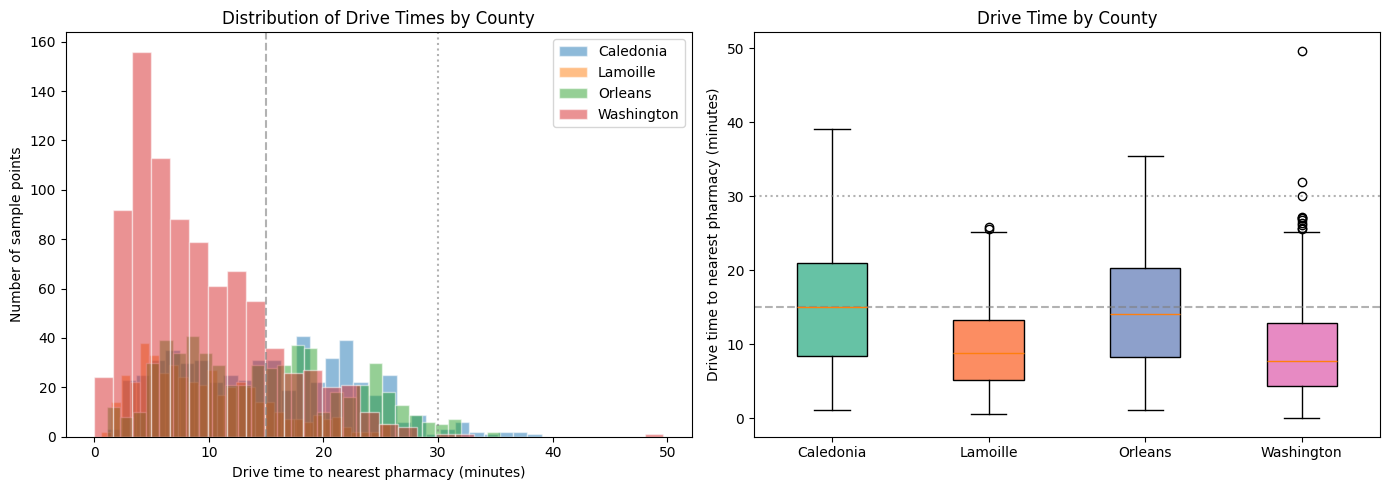

Saved to data/drive_time_stats.png


In [22]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
ax = axes[0]
for county_name in sorted(TARGET_COUNTIES.keys()):
    subset = drive_times_df[drive_times_df["county_name"] == county_name]
    ax.hist(
        subset["min_drive_minutes"],
        bins=30,
        alpha=0.5,
        label=county_name,
        edgecolor="white",
    )
ax.set_xlabel("Drive time to nearest pharmacy (minutes)")
ax.set_ylabel("Number of sample points")
ax.set_title("Distribution of Drive Times by County")
ax.legend()
ax.axvline(x=15, color="gray", linestyle="--", alpha=0.6, label="15 min")
ax.axvline(x=30, color="gray", linestyle=":", alpha=0.6, label="30 min")

# Box plot
ax = axes[1]
county_order = sorted(TARGET_COUNTIES.keys())
plot_data = [
    drive_times_df[drive_times_df["county_name"] == c]["min_drive_minutes"].values
    for c in county_order
]
bp = ax.boxplot(plot_data, labels=county_order, patch_artist=True)
colors = sns.color_palette("Set2", len(county_order))
for patch, color in zip(bp["boxes"], colors):
    patch.set_facecolor(color)
ax.set_ylabel("Drive time to nearest pharmacy (minutes)")
ax.set_title("Drive Time by County")
ax.axhline(y=15, color="gray", linestyle="--", alpha=0.6)
ax.axhline(y=30, color="gray", linestyle=":", alpha=0.6)

plt.tight_layout()
plt.savefig(DATA_DIR / "drive_time_stats.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved to data/drive_time_stats.png")

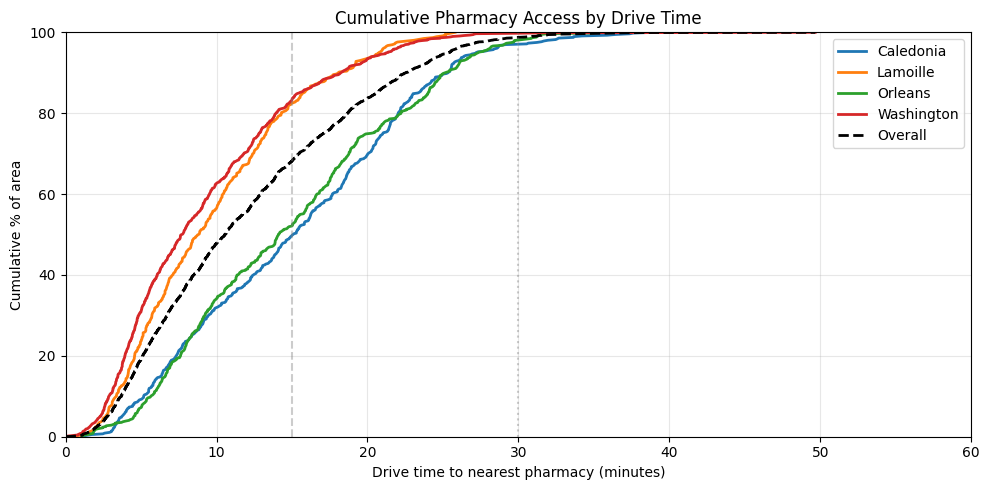

Saved to data/drive_time_cdf.png


In [23]:
# CDF: cumulative percentage of area within X minutes of a pharmacy
fig, ax = plt.subplots(figsize=(10, 5))

for county_name in sorted(TARGET_COUNTIES.keys()):
    subset = drive_times_df[drive_times_df["county_name"] == county_name]["min_drive_minutes"].sort_values()
    cdf = np.arange(1, len(subset) + 1) / len(subset) * 100
    ax.plot(subset.values, cdf, label=county_name, linewidth=2)

overall = drive_times_df["min_drive_minutes"].sort_values()
cdf_all = np.arange(1, len(overall) + 1) / len(overall) * 100
ax.plot(overall.values, cdf_all, label="Overall", linewidth=2, color="black", linestyle="--")

ax.set_xlabel("Drive time to nearest pharmacy (minutes)")
ax.set_ylabel("Cumulative % of area")
ax.set_title("Cumulative Pharmacy Access by Drive Time")
ax.legend()
ax.set_xlim(0, max(60, overall.max()))
ax.set_ylim(0, 100)
ax.axvline(x=15, color="gray", linestyle="--", alpha=0.4)
ax.axvline(x=30, color="gray", linestyle=":", alpha=0.4)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(DATA_DIR / "drive_time_cdf.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved to data/drive_time_cdf.png")

## Save Map to HTML

Export the interactive map as a standalone HTML file for sharing.

In [ ]:
map_path = DATA_DIR / "pharmacy_access_map.html"
m.save(str(map_path))
print(f"Interactive map saved to {map_path}")